# CSE253 Assignment 2: Symbolic MIDI Generation



## 1. Overview and Task Definitions

This assignment studies two symbolic MIDI generation tasks:

- **Task 1: symbolic unconditioned generation.** The system generates a new MIDI sequence from a beginning seed and a density control token.
- **Task 2: symbolic conditioned continuation.** The system receives a real MIDI prefix and generates a continuation; evaluation emphasizes the generated continuation, not the real prefix.

The final route uses the **Nottingham** dataset because it is shorter, simpler, and more stable for symbolic generation than the harder MAESTRO piano dataset. MAESTRO was explored earlier as a harder expressive-piano dataset, but it is not used as the final main route.

Final model:

- Density-conditioned GPT2-style causal Transformer
- Transformer initialized from scratch

Baseline:

- Markov / n-gram symbolic baseline


## 2. Reproducible Setup


In [3]:
from __future__ import annotations

import csv
import json
import math
import os
import platform
import random
import shutil
import sys
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from itertools import cycle, product
from pathlib import Path

import matplotlib.pyplot as plt
import mido
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import GPT2Config, GPT2LMHeadModel

try:
    from miditok import REMI, TokenizerConfig
    from symusic import Score
    MIDITOK_AVAILABLE = True
except Exception as exc:
    MIDITOK_AVAILABLE = False
    MIDITOK_IMPORT_ERROR = repr(exc)

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "nottingham-dataset-master" / "MIDI").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "nottingham-dataset-master" / "MIDI"
os.chdir(PROJECT_ROOT)

def relpath(path: Path) -> str:
    path = Path(path)
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT))
    except Exception:
        return str(path)

FINAL_ROOT = Path("outputs/final")
CHECKPOINT_DIR = FINAL_ROOT / "checkpoints"
METRICS_DIR = FINAL_ROOT / "metrics"
CANDIDATE_DIR = FINAL_ROOT / "candidates"
RAW_CANDIDATE_DIR = CANDIDATE_DIR / "raw"
EVALUATION_DIR = FINAL_ROOT / "evaluation"
FIGURE_DIR = FINAL_ROOT / "figures"
LOG_DIR = FINAL_ROOT / "logs"

RUN_DATA_ANALYSIS = True
RUN_MARKOV_BASELINE = True
RUN_TRANSFORMER_TRAINING = True
RUN_GENERATION = True
RUN_EVALUATION = True

# Submission and export are intentionally disabled for this review pass.
CREATE_SUBMISSION_FILES = False
EXPORT_HTML = False
RESET_FINAL_OUTPUTS = False
VERBOSE_TRAINING = False

SEED = 253
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if RESET_FINAL_OUTPUTS:
    shutil.rmtree(FINAL_ROOT, ignore_errors=True)

for directory in [CHECKPOINT_DIR, METRICS_DIR, CANDIDATE_DIR, RAW_CANDIDATE_DIR, EVALUATION_DIR, FIGURE_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Nottingham data:", DATA_DIR, "exists=", DATA_DIR.exists())
print("Submission disabled:", not CREATE_SUBMISSION_FILES)
print("HTML export disabled:", not EXPORT_HTML)


Project root: C:\Users\GD\OneDrive\Desktop\CSE253\assignment2-music-generation
Python: 3.11.15
Platform: Windows-10-10.0.26200-SP0
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Nottingham data: C:\Users\GD\OneDrive\Desktop\CSE253\assignment2-music-generation\data\nottingham-dataset-master\MIDI exists= True
Submission disabled: True
HTML export disabled: True


## 3. Dataset: Nottingham


The final experiment uses the Nottingham symbolic MIDI collection. Compared with MAESTRO, Nottingham pieces are shorter and structurally simpler, which makes it a better final route for stable symbolic unconditioned generation and conditioned continuation. The dataset analysis below checks whether the corpus has enough notes, reasonable durations, useful pitch coverage, and a density distribution that can support density-conditioned training.

The duration, note-count, note-density, token-length, and pitch-class figures are used as sanity checks before training. The density bucket plot later determines how training windows are balanced across low, medium, and high note density.


In [4]:
MIDI_EXTENSIONS = {".mid", ".midi"}

def discover_midi_files(root: Path) -> list[Path]:
    return sorted(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in MIDI_EXTENSIONS)

def read_note_events(path: Path) -> tuple[list[dict[str, int]], int]:
    midi = mido.MidiFile(path)
    notes = []
    active = defaultdict(list)
    for track in midi.tracks:
        absolute = 0
        for message in track:
            absolute += message.time
            if message.type == "note_on" and getattr(message, "velocity", 0) > 0:
                key = (int(getattr(message, "channel", 0)), int(message.note))
                active[key].append((absolute, int(message.velocity)))
            elif message.type in {"note_off", "note_on"}:
                key = (int(getattr(message, "channel", 0)), int(message.note))
                if active.get(key):
                    start, velocity = active[key].pop(0)
                    notes.append({
                        "start": int(start),
                        "end": int(max(start + 1, absolute)),
                        "pitch": int(message.note),
                        "velocity": int(max(1, min(127, velocity))),
                        "channel": int(getattr(message, "channel", 0)),
                    })
    notes.sort(key=lambda n: (n["start"], n["pitch"], n["end"]))
    return notes, midi.ticks_per_beat or 480

def midi_statistics(path: Path) -> dict[str, object]:
    try:
        notes, ticks_per_beat = read_note_events(path)
        if not notes:
            return {"path": str(path), "valid": False, "note_count": 0, "duration_seconds": 0.0}
        starts = [n["start"] for n in notes]
        ends = [n["end"] for n in notes]
        pitches = [n["pitch"] for n in notes]
        duration = max(ends) / ticks_per_beat * 0.5
        starts_seconds = sorted(s / ticks_per_beat * 0.5 for s in starts)
        gaps = [b - a for a, b in zip(starts_seconds, starts_seconds[1:])]
        return {
            "path": relpath(path),
            "valid": True,
            "note_count": len(notes),
            "duration_seconds": duration,
            "notes_per_second": len(notes) / max(duration, 1e-9),
            "pitch_min": min(pitches),
            "pitch_max": max(pitches),
            "pitch_range": max(pitches) - min(pitches),
            "unique_pitch_count": len(set(pitches)),
            "max_gap_seconds": max(gaps) if gaps else 0.0,
        }
    except Exception as exc:
        return {"path": relpath(path), "valid": False, "note_count": 0, "duration_seconds": 0.0, "error": repr(exc)}

midi_files = discover_midi_files(DATA_DIR)
print("MIDI file count:", len(midi_files))
if not midi_files:
    raise FileNotFoundError(f"No MIDI files found under {DATA_DIR}. The notebook expects the Nottingham dataset to already exist locally.")
display(pd.DataFrame({"sample_file": [relpath(p) for p in midi_files[:10]]}))

if RUN_DATA_ANALYSIS:
    dataset_rows = [midi_statistics(path) for path in midi_files]
    dataset_df = pd.DataFrame(dataset_rows)
    valid_dataset_df = dataset_df[dataset_df["valid"] == True].copy()
else:
    dataset_df = pd.DataFrame()
    valid_dataset_df = pd.DataFrame()

display(valid_dataset_df[["note_count", "duration_seconds", "notes_per_second", "pitch_min", "pitch_max", "pitch_range", "unique_pitch_count"]].describe())

basic_dataset_summary = pd.DataFrame([{
    "num_files": len(midi_files),
    "valid_files": len(valid_dataset_df),
    "total_notes": int(valid_dataset_df["note_count"].sum()) if not valid_dataset_df.empty else 0,
    "mean_duration": float(valid_dataset_df["duration_seconds"].mean()) if not valid_dataset_df.empty else 0.0,
    "median_duration": float(valid_dataset_df["duration_seconds"].median()) if not valid_dataset_df.empty else 0.0,
    "mean_note_count": float(valid_dataset_df["note_count"].mean()) if not valid_dataset_df.empty else 0.0,
    "median_note_count": float(valid_dataset_df["note_count"].median()) if not valid_dataset_df.empty else 0.0,
    "mean_notes_per_second": float(valid_dataset_df["notes_per_second"].mean()) if not valid_dataset_df.empty else 0.0,
    "median_notes_per_second": float(valid_dataset_df["notes_per_second"].median()) if not valid_dataset_df.empty else 0.0,
}])
display(basic_dataset_summary)


MIDI file count: 3089


,sample_file
0,data\nottingham-dataset-master\MIDI\ashover1.mid
1,data\nottingham-dataset-master\MIDI\ashover10.mid
2,data\nottingham-dataset-master\MIDI\ashover11.mid
3,data\nottingham-dataset-master\MIDI\ashover12.mid
4,data\nottingham-dataset-master\MIDI\ashover13.mid
5,data\nottingham-dataset-master\MIDI\ashover14.mid
6,data\nottingham-dataset-master\MIDI\ashover15.mid
7,data\nottingham-dataset-master\MIDI\ashover16.mid
8,data\nottingham-dataset-master\MIDI\ashover17.mid
9,data\nottingham-dataset-master\MIDI\ashover18.mid


,note_count,duration_seconds,notes_per_second,pitch_min,pitch_max,pitch_range,unique_pitch_count
count,3089.000000,3089.000000,3089.000000,3089.000000,3089.000000,3089.000000,3089.000000
mean,230.667530,67.409922,3.499633,46.029136,71.630949,25.601813,14.689544
std,189.063025,44.833690,1.561012,12.645646,12.699002,12.731995,5.894014
min,7.000000,11.000000,0.529412,36.000000,45.000000,7.000000,3.000000
25%,130.000000,49.250000,2.303030,36.000000,55.000000,17.000000,10.000000
50%,180.000000,64.000000,3.147208,38.000000,79.000000,19.000000,12.000000
75%,285.000000,66.000000,4.454545,62.000000,81.000000,43.000000,20.000000
max,3868.000000,769.500000,13.431818,74.000000,88.000000,52.000000,38.000000


,num_files,valid_files,total_notes,mean_duration,median_duration,mean_note_count,median_note_count,mean_notes_per_second,median_notes_per_second
0,3089,3089,712532,67.409922,64.0,230.66753,180.0,3.499633,3.147208


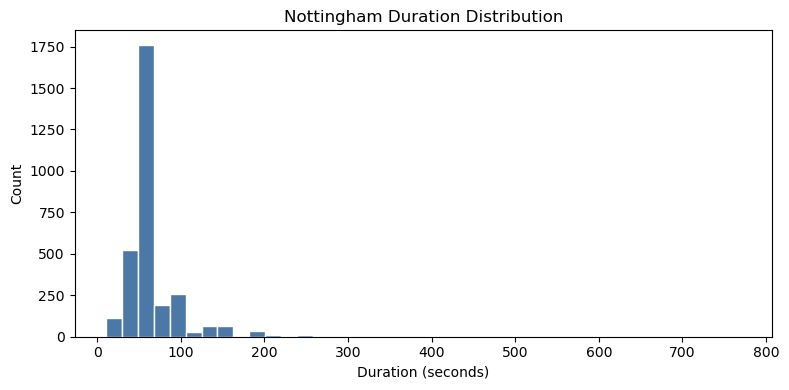

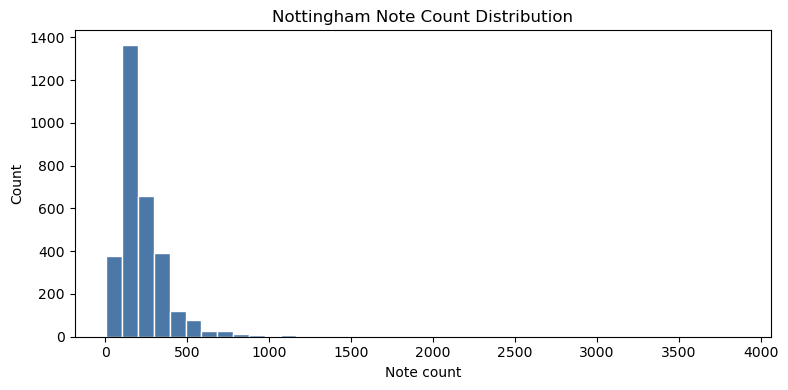

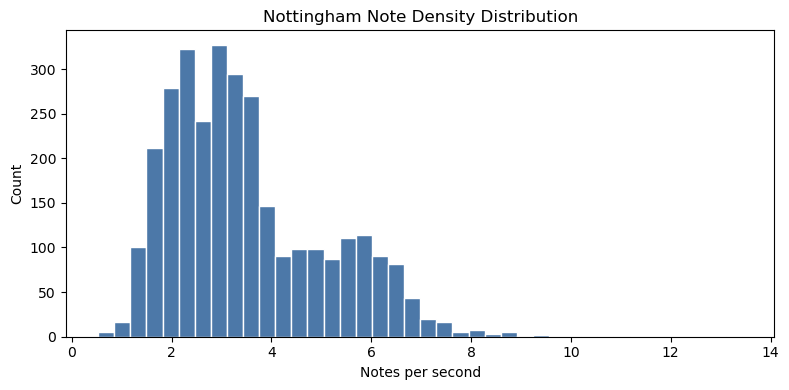

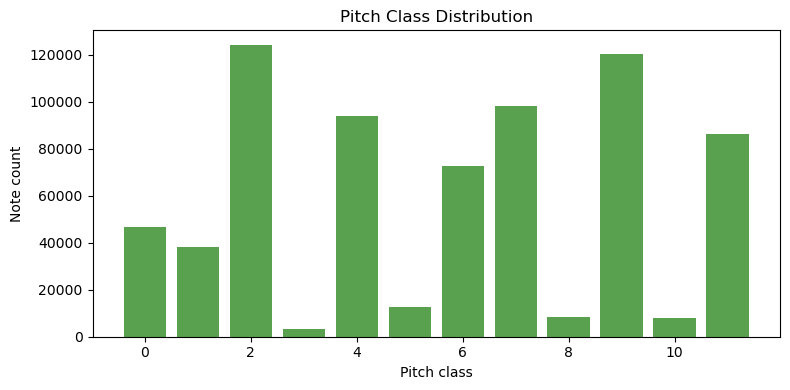

In [5]:
def save_and_show_hist(series, filename, title, xlabel, bins=40):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(series.dropna(), bins=bins, color="#4C78A8", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    fig.tight_layout()
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=150)
    plt.show()
    return path

if RUN_DATA_ANALYSIS and not valid_dataset_df.empty:
    save_and_show_hist(valid_dataset_df["duration_seconds"], "duration_histogram.png", "Nottingham Duration Distribution", "Duration (seconds)")
    save_and_show_hist(valid_dataset_df["note_count"], "note_count_histogram.png", "Nottingham Note Count Distribution", "Note count")
    save_and_show_hist(valid_dataset_df["notes_per_second"], "note_density_histogram.png", "Nottingham Note Density Distribution", "Notes per second")

    pitch_counts = Counter()
    for path in midi_files:
        notes, _ = read_note_events(path)
        pitch_counts.update([n["pitch"] % 12 for n in notes])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(12), [pitch_counts[i] for i in range(12)], color="#59A14F")
    ax.set_title("Pitch Class Distribution")
    ax.set_xlabel("Pitch class")
    ax.set_ylabel("Note count")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "pitch_class_histogram.png", dpi=150)
    plt.show()


## 4. MIDI Preprocessing and Tokenization


MIDI is converted to REMI-style symbolic event tokens. Bar and Position events describe where time moves in the measure; Pitch, Velocity, and Duration events describe the actual note content. A failure mode in earlier experiments was that generation could advance time for a long duration while producing too few complete Pitch/Velocity/Duration note events. To address that, each training window receives a density control token: `low`, `med`, or `high`.

The density labels are computed from the local token window rather than from a hand-written musical category. During generation, the Transformer can be prompted with a target density so that rollouts are less likely to become long and sparse.


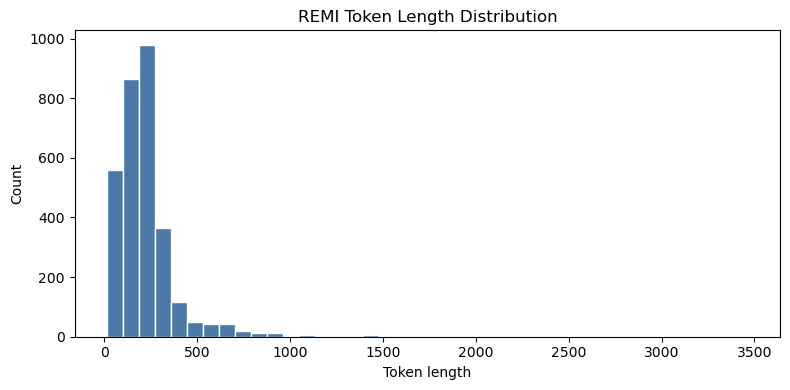

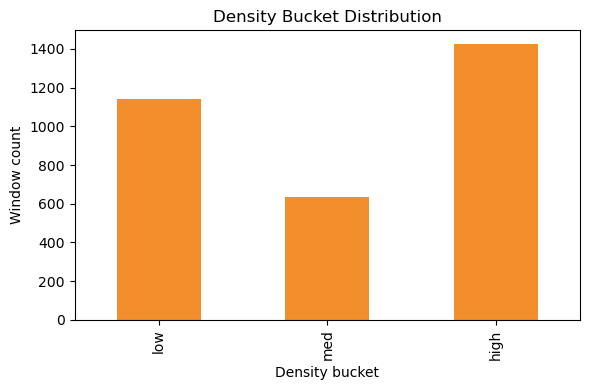

,example_file,token_sequence_length,window_length,density_label
0,data\nottingham-dataset-master\MIDI\ashover1.mid,121,121,low


First token ids: [305, 486, 58, 265, 287, 55, 422, 404, 352, 387, 277, 55, 265, 190, 388, 293, 279, 486, 58, 265, 287, 55, 422, 404, 352, 387, 277, 499, 49, 276]
First token labels: ['', '', 'Pitch', '', '', 'Pitch', '', '', '', '', '', 'Pitch', '', 'Position', '', '', '', '', 'Pitch', '']


,dataset,num_files,total_notes,mean_duration,median_duration,mean_note_count,median_note_count,mean_notes_per_second,median_notes_per_second,mean_token_length,...,density_med,density_high,valid_midi_count,train_file_count,valid_file_count,train_window_count,valid_window_count,token_min,token_max,token_mean
0,Nottingham,3089,712532,67.409922,64.0,230.66753,180.0,3.499633,3.147208,222.213014,...,637,1425,3089,2780,309,2889,316,13,3465,222.213014


In [6]:
if not MIDITOK_AVAILABLE:
    raise ImportError(f"MidiTok / symusic import failed: {MIDITOK_IMPORT_ERROR}")

class NotebookREMITokenizer:
    def __init__(self, num_velocities: int = 8, vocab_size: int = 512):
        config = TokenizerConfig(num_velocities=num_velocities, use_chords=False, use_programs=False)
        self.tokenizer = REMI(config)
        self.target_vocab_size = vocab_size

    def fit(self, files: list[Path]) -> None:
        self.tokenizer.train(vocab_size=max(self.target_vocab_size, len(self.tokenizer) + 64), files_paths=[str(p) for p in files])

    @property
    def vocab_size(self) -> int:
        return len(self.tokenizer)

    def encode_file(self, path: Path) -> list[int]:
        encoded = self.tokenizer(Score(str(path)))
        sequence = encoded[0] if isinstance(encoded, list) else encoded
        ids = getattr(sequence, "ids", sequence)
        return [int(token_id) for token_id in ids]

    def decode_ids(self, ids: list[int], output_path: Path) -> None:
        score = self.tokenizer.decode([ids])
        output_path.parent.mkdir(parents=True, exist_ok=True)
        if hasattr(score, "dump_midi"):
            score.dump_midi(str(output_path))
        else:
            score.write(str(output_path))

    def token_label(self, token_id: int) -> str:
        try:
            return str(self.tokenizer.token_id_type(int(token_id)))
        except Exception:
            vocab = getattr(self.tokenizer, "vocab", {})
            inverse = {int(v): str(k) for k, v in vocab.items()}
            return inverse.get(int(token_id), "")

def token_type_counts(tokenizer: NotebookREMITokenizer, ids: list[int]) -> dict[str, float]:
    counts = Counter()
    for token_id in ids:
        label = tokenizer.token_label(token_id)
        token_type = label.split("_", 1)[0]
        if token_type == "Pitch":
            counts["pitch"] += 1
        elif token_type == "Bar":
            counts["bar"] += 1
        elif token_type == "Position":
            counts["position"] += 1
        elif token_type == "Velocity":
            counts["velocity"] += 1
        elif token_type == "Duration":
            counts["duration"] += 1
        else:
            counts["other"] += 1
    total = max(len(ids), 1)
    return {**counts, "pitch_per_100_tokens": counts["pitch"] * 100.0 / total, "pitch_ratio": counts["pitch"] / total}

def density_label(tokenizer: NotebookREMITokenizer, ids: list[int]) -> str:
    stats = token_type_counts(tokenizer, ids)
    pitch_count = int(stats.get("pitch", 0))
    pitch_per_100 = float(stats.get("pitch_per_100_tokens", 0.0))
    if pitch_count < 30 or pitch_per_100 < 10.0:
        return "low"
    if pitch_per_100 >= 20.0:
        return "high"
    return "med"

def make_lm_windows(sequences: list[list[int]], block_size: int, stride: int) -> list[list[int]]:
    windows = []
    target_len = block_size + 1
    for seq in sequences:
        if len(seq) < 2:
            continue
        if len(seq) <= target_len:
            windows.append(seq)
        else:
            for start in range(0, len(seq) - target_len + 1, stride):
                windows.append(seq[start:start + target_len])
    return windows

def split_files(files: list[Path], valid_fraction: float = 0.1) -> tuple[list[Path], list[Path]]:
    valid_count = max(1, min(len(files) - 1, round(len(files) * valid_fraction)))
    return files[:-valid_count], files[-valid_count:]

BLOCK_SIZE = 512
STRIDE = 256
VALID_FRACTION = 0.1

tokenizer = NotebookREMITokenizer(num_velocities=8, vocab_size=512)
if RUN_DATA_ANALYSIS:
    tokenizer.fit(midi_files)
    encoded_by_file = {}
    skipped_files = []
    for path in midi_files:
        try:
            ids = tokenizer.encode_file(path)
            if ids:
                encoded_by_file[path] = ids
        except Exception as exc:
            skipped_files.append({"path": relpath(path), "error": repr(exc)})
else:
    encoded_by_file = {}
    skipped_files = []

token_lengths = pd.Series([len(ids) for ids in encoded_by_file.values()], name="token_length")
if len(token_lengths):
    save_and_show_hist(token_lengths, "token_length_histogram.png", "REMI Token Length Distribution", "Token length")

train_files, valid_files = split_files([p for p in midi_files if p in encoded_by_file], VALID_FRACTION)
train_sequences = [encoded_by_file[p] for p in train_files]
valid_sequences = [encoded_by_file[p] for p in valid_files]
train_windows_raw = make_lm_windows(train_sequences, BLOCK_SIZE, STRIDE)
valid_windows_raw = make_lm_windows(valid_sequences, BLOCK_SIZE, STRIDE)

density_rows = [{"density": density_label(tokenizer, w), "token_length": len(w)} for w in train_windows_raw + valid_windows_raw]
density_df = pd.DataFrame(density_rows)
if not density_df.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    density_df["density"].value_counts().reindex(["low", "med", "high"]).fillna(0).plot(kind="bar", ax=ax, color="#F28E2B")
    ax.set_title("Density Bucket Distribution")
    ax.set_xlabel("Density bucket")
    ax.set_ylabel("Window count")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "density_bucket_bar.png", dpi=150)
    plt.show()

example_path = train_files[0]
example_ids = encoded_by_file[example_path]
example_window = train_windows_raw[0]
display(pd.DataFrame([{
    "example_file": relpath(example_path),
    "token_sequence_length": len(example_ids),
    "window_length": len(example_window),
    "density_label": density_label(tokenizer, example_window),
}]))
print("First token ids:", example_ids[:30])
print("First token labels:", [tokenizer.token_label(i) for i in example_ids[:20]])

dataset_summary = pd.DataFrame([{
    "dataset": "Nottingham",
    "num_files": len(midi_files),
    "total_notes": int(valid_dataset_df["note_count"].sum()) if not valid_dataset_df.empty else 0,
    "mean_duration": float(valid_dataset_df["duration_seconds"].mean()) if not valid_dataset_df.empty else 0.0,
    "median_duration": float(valid_dataset_df["duration_seconds"].median()) if not valid_dataset_df.empty else 0.0,
    "mean_note_count": float(valid_dataset_df["note_count"].mean()) if not valid_dataset_df.empty else 0.0,
    "median_note_count": float(valid_dataset_df["note_count"].median()) if not valid_dataset_df.empty else 0.0,
    "mean_notes_per_second": float(valid_dataset_df["notes_per_second"].mean()) if not valid_dataset_df.empty else 0.0,
    "median_notes_per_second": float(valid_dataset_df["notes_per_second"].median()) if not valid_dataset_df.empty else 0.0,
    "mean_token_length": float(token_lengths.mean()) if len(token_lengths) else 0.0,
    "density_low": int((density_df["density"] == "low").sum()) if not density_df.empty else 0,
    "density_med": int((density_df["density"] == "med").sum()) if not density_df.empty else 0,
    "density_high": int((density_df["density"] == "high").sum()) if not density_df.empty else 0,
    "valid_midi_count": len(encoded_by_file),
    "train_file_count": len(train_files),
    "valid_file_count": len(valid_files),
    "train_window_count": len(train_windows_raw),
    "valid_window_count": len(valid_windows_raw),
    "token_min": int(token_lengths.min()) if len(token_lengths) else 0,
    "token_max": int(token_lengths.max()) if len(token_lengths) else 0,
    "token_mean": float(token_lengths.mean()) if len(token_lengths) else 0.0,
}])
dataset_summary.to_csv(EVALUATION_DIR / "dataset_summary.csv", index=False)
display(dataset_summary)


Bar and Position tokens advance musical time. Pitch, Velocity, and Duration tokens form note events. Earlier experiments showed that a model can generate long sequences with many time-advance tokens but too few complete notes, producing long sparse MIDI. The final Transformer therefore prepends a density-control token to each training window.


## 5. Markov / n-gram Baseline


The Markov baseline is a simple symbolic n-gram model over token ids. It learns local transition statistics and can generate either from a learned start state or from a conditioned prefix. This baseline is interpretable and useful as a stability check, but it has limited long-range musical structure compared with a neural next-token model.


In [7]:
class MarkovNGram:
    def __init__(self, order: int = 3, seed: int = 253):
        self.order = order
        self.rng = random.Random(seed)
        self.transitions = defaultdict(Counter)
        self.starts = []
        self.vocab = []

    def fit(self, sequences: list[list[int]]) -> None:
        vocab = set()
        for seq in sequences:
            if len(seq) <= self.order:
                continue
            self.starts.append(tuple(seq[:self.order]))
            vocab.update(seq)
            padded = list(seq)
            for i in range(len(padded) - self.order):
                context = tuple(padded[i:i + self.order])
                nxt = padded[i + self.order]
                self.transitions[context][nxt] += 1
        self.vocab = sorted(vocab)

    def _draw(self, counts: Counter) -> int:
        total = sum(counts.values())
        threshold = self.rng.uniform(0, total)
        cumulative = 0
        for token, count in counts.items():
            cumulative += count
            if cumulative >= threshold:
                return int(token)
        return int(next(iter(counts)))

    def sample(self, max_tokens: int, prefix: list[int] | None = None) -> list[int]:
        if prefix:
            output = list(prefix)
        else:
            output = list(self.rng.choice(self.starts))
        while len(output) < max_tokens:
            context = tuple(output[-self.order:])
            counts = self.transitions.get(context)
            if not counts:
                context = self.rng.choice(self.starts)
                counts = self.transitions[context]
            output.append(self._draw(counts))
        return output

def decode_to_midi(ids: list[int], path: Path) -> bool:
    try:
        tokenizer.decode_ids(ids, path)
        notes, _ = read_note_events(path)
        return len(notes) > 0
    except Exception as exc:
        print("Decode failed:", path, repr(exc))
        return False

markov = MarkovNGram(order=3, seed=SEED)
if RUN_MARKOV_BASELINE:
    markov.fit(train_windows_raw)
    markov_unconditioned_ids = markov.sample(512)
    conditioned_prefix_ids = valid_windows_raw[0][:128]
    markov_conditioned_ids = markov.sample(640, prefix=conditioned_prefix_ids)
    decode_to_midi(markov_unconditioned_ids, CANDIDATE_DIR / "markov_unconditioned.mid")
    decode_to_midi(markov_conditioned_ids, CANDIDATE_DIR / "markov_conditioned.mid")
    print("Saved Markov baseline MIDI files.")


Saved Markov baseline MIDI files.


## 6. Density-conditioned GPT2-style Transformer


The main model is a GPT2-style causal Transformer trained as a next-token predictor over the REMI vocabulary plus three density-control tokens. It is initialized from scratch. Each training window is prepended with a `low`, `med`, or `high` density token, and the training sampler balances windows toward a medium/high-density distribution to reduce sparse rollouts.

The final reproducible setting trains up to 12,000 steps with validation every 250 steps. Generation uses the checkpoint with the best validation loss.


In [8]:
DENSITY_LABELS = ["low", "med", "high"]
DENSITY_TARGET = {"low": 0.10, "med": 0.60, "high": 0.30}
BASE_VOCAB_SIZE = tokenizer.vocab_size
CONTROL_TOKEN_IDS = {label: BASE_VOCAB_SIZE + idx for idx, label in enumerate(DENSITY_LABELS)}
VOCAB_SIZE = BASE_VOCAB_SIZE + len(CONTROL_TOKEN_IDS)

BATCH_SIZE = 16
N_EMBD = 256
N_LAYER = 4
N_HEAD = 4
DROPOUT = 0.1
LR = 0.0003
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
EVAL_INTERVAL = 250
MAX_STEPS_FULL = 12000
MAX_STEPS_QUICK = 100
USE_QUICK_RUN = False
MAX_STEPS = MAX_STEPS_QUICK if USE_QUICK_RUN else MAX_STEPS_FULL
PROGRESS_PRINT_INTERVAL = 1000

def controlled_window(window: list[int], label: str) -> list[int]:
    return [CONTROL_TOKEN_IDS[label], *window]

def density_balanced_windows(windows: list[list[int]], balance: bool = True) -> tuple[list[list[int]], dict[str, object]]:
    buckets = {label: [] for label in DENSITY_LABELS}
    for window in windows:
        buckets[density_label(tokenizer, window)].append(window)
    selected = []
    if balance:
        total = sum(len(v) for v in buckets.values())
        for label in DENSITY_LABELS:
            if not buckets[label]:
                continue
            count = int(round(total * DENSITY_TARGET[label]))
            selected.extend((label, random.choice(buckets[label])) for _ in range(max(1, count)))
    else:
        for label, items in buckets.items():
            selected.extend((label, item) for item in items)
    random.shuffle(selected)
    return [controlled_window(window, label) for label, window in selected], {
        "raw_distribution": {label: len(buckets[label]) for label in DENSITY_LABELS},
        "selected_distribution": dict(Counter(label for label, _ in selected)),
        "target_distribution": DENSITY_TARGET if balance else None,
    }

train_windows, train_density_summary = density_balanced_windows(train_windows_raw, balance=True)
valid_windows, valid_density_summary = density_balanced_windows(valid_windows_raw, balance=False)
print("Control token ids:", CONTROL_TOKEN_IDS)
print("Train density summary:", train_density_summary)
print("Validation density summary:", valid_density_summary)

def make_batches(windows: list[list[int]], block_size: int, batch_size: int):
    examples = []
    for window in windows:
        trimmed = window[:block_size + 1]
        if len(trimmed) < block_size + 1:
            trimmed = trimmed + [trimmed[-1]] * (block_size + 1 - len(trimmed))
        examples.append(trimmed)
    for start in range(0, len(examples), batch_size):
        batch = torch.tensor(examples[start:start + batch_size], dtype=torch.long)
        yield batch[:, :-1], batch[:, 1:]

def token_weight_vector() -> torch.Tensor:
    weights = torch.ones(VOCAB_SIZE, dtype=torch.float32)
    for token_id in range(BASE_VOCAB_SIZE):
        label = tokenizer.token_label(token_id)
        token_type = label.split("_", 1)[0]
        if token_type == "Pitch":
            weights[token_id] = 1.5
        elif token_type in {"Velocity", "Duration"}:
            weights[token_id] = 1.2
    return weights

def weighted_ce_loss(logits, labels, weights):
    flat_loss = torch.nn.functional.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), reduction="none")
    flat_labels = labels.reshape(-1)
    flat_weights = weights.to(labels.device)[flat_labels]
    return (flat_loss * flat_weights).sum() / flat_weights.sum().clamp_min(1e-6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = GPT2Config(
    vocab_size=VOCAB_SIZE,
    n_positions=BLOCK_SIZE,
    n_ctx=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_layer=N_LAYER,
    n_head=N_HEAD,
    resid_pdrop=DROPOUT,
    embd_pdrop=DROPOUT,
    attn_pdrop=DROPOUT,
    bos_token_id=0,
    eos_token_id=1,
)
model = GPT2LMHeadModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_weights = token_weight_vector()

print("Transformer initialized from scratch.")
print("Parameter count:", sum(p.numel() for p in model.parameters()))


Control token ids: {'low': 512, 'med': 513, 'high': 514}
Train density summary: {'raw_distribution': {'low': 1089, 'med': 557, 'high': 1243}, 'selected_distribution': {'high': 867, 'med': 1733, 'low': 289}, 'target_distribution': {'low': 0.1, 'med': 0.6, 'high': 0.3}}
Validation density summary: {'raw_distribution': {'low': 54, 'med': 80, 'high': 182}, 'selected_distribution': {'med': 80, 'high': 182, 'low': 54}, 'target_distribution': None}
Transformer initialized from scratch.
Parameter count: 3422464


In [9]:
def evaluate_model_loss(model, windows):
    model.eval()
    losses = []
    with torch.no_grad():
        for inputs, labels in make_batches(windows, BLOCK_SIZE, BATCH_SIZE):
            outputs = model(input_ids=inputs.to(device))
            loss = weighted_ce_loss(outputs.logits, labels.to(device), loss_weights)
            losses.append(float(loss.detach().cpu()))
    model.train()
    return sum(losses) / max(len(losses), 1)

training_history = []
best_valid_loss = float("inf")
best_step = 0
step = 0
start_time = time.perf_counter()

if RUN_TRANSFORMER_TRAINING:
    model.train()
    while step < MAX_STEPS:
        batch_windows = list(train_windows)
        random.shuffle(batch_windows)
        for inputs, labels in make_batches(batch_windows, BLOCK_SIZE, BATCH_SIZE):
            outputs = model(input_ids=inputs.to(device))
            loss = weighted_ce_loss(outputs.logits, labels.to(device), loss_weights)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            optimizer.zero_grad()
            step += 1
            if step % EVAL_INTERVAL == 0 or step == 1:
                valid_loss = evaluate_model_loss(model, valid_windows)
                row = {
                    "step": step,
                    "train_loss": float(loss.detach().cpu()),
                    "valid_loss": valid_loss,
                    "valid_perplexity": math.exp(valid_loss) if valid_loss < 20 else float("inf"),
                    "learning_rate": LR,
                }
                training_history.append(row)
                if valid_loss < best_valid_loss:
                    best_valid_loss = valid_loss
                    best_step = step
                    torch.save({
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "config": config.to_dict(),
                        "step": step,
                        "valid_loss": valid_loss,
                        "control_token_ids": CONTROL_TOKEN_IDS,
                        "base_vocab_size": BASE_VOCAB_SIZE,
                    }, CHECKPOINT_DIR / "best_transformer.pt")
                if VERBOSE_TRAINING or step == 1 or step % PROGRESS_PRINT_INTERVAL == 0 or step == MAX_STEPS:
                    print(
                        f"step={step} train_loss={row['train_loss']:.4f} "
                        f"valid_loss={row['valid_loss']:.4f} valid_ppl={row['valid_perplexity']:.3f} "
                        f"best_step={best_step}"
                    )
            if step >= MAX_STEPS:
                break

history_df = pd.DataFrame(training_history)
history_df.to_csv(METRICS_DIR / "training_history.csv", index=False)
summary = {
    "dataset_name": "final_nottingham_density",
    "file_count": len(midi_files),
    "train_file_count": len(train_files),
    "valid_file_count": len(valid_files),
    "base_vocab_size": BASE_VOCAB_SIZE,
    "vocab_size": VOCAB_SIZE,
    "control_token_ids": CONTROL_TOKEN_IDS,
    "train_window_count": len(train_windows_raw),
    "valid_window_count": len(valid_windows_raw),
    "train_density_summary": train_density_summary,
    "valid_density_summary": valid_density_summary,
    "transformer": {
        "scratch_initialized": True,
        "pretrained_loaded": False,
        "parameter_count": sum(p.numel() for p in model.parameters()),
        "steps_completed": step,
        "best_step": best_step,
        "best_valid_loss": best_valid_loss if best_valid_loss < float("inf") else None,
        "best_valid_perplexity": math.exp(best_valid_loss) if best_valid_loss < 20 else None,
        "runtime_seconds": time.perf_counter() - start_time,
    },
}
(METRICS_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(pd.DataFrame([summary["transformer"]]))


step=1 train_loss=6.1542 valid_loss=5.5258 valid_ppl=251.096 best_step=1
step=1000 train_loss=1.0942 valid_loss=1.0317 valid_ppl=2.806 best_step=1000
step=2000 train_loss=0.3455 valid_loss=0.9055 valid_ppl=2.473 best_step=2000
step=3000 train_loss=0.3172 valid_loss=0.8126 valid_ppl=2.254 best_step=3000
step=4000 train_loss=0.1459 valid_loss=0.7828 valid_ppl=2.188 best_step=3750
step=5000 train_loss=0.1213 valid_loss=0.7452 valid_ppl=2.107 best_step=4500
step=6000 train_loss=0.1742 valid_loss=0.7704 valid_ppl=2.161 best_step=5500
step=7000 train_loss=0.1005 valid_loss=0.7673 valid_ppl=2.154 best_step=5500
step=8000 train_loss=0.1258 valid_loss=0.7687 valid_ppl=2.157 best_step=5500
step=9000 train_loss=0.0817 valid_loss=0.7882 valid_ppl=2.199 best_step=5500
step=10000 train_loss=0.0767 valid_loss=0.7888 valid_ppl=2.201 best_step=5500
step=11000 train_loss=0.0851 valid_loss=0.8161 valid_ppl=2.262 best_step=5500
step=12000 train_loss=0.0635 valid_loss=0.8297 valid_ppl=2.293 best_step=5500


,scratch_initialized,pretrained_loaded,parameter_count,steps_completed,best_step,best_valid_loss,best_valid_perplexity,runtime_seconds
0,True,False,3422464,12000,5500,0.721808,2.058152,392.360344


## 7. Training Curves and Checkpoint Selection


The curves below show train loss, validation loss, and checkpoint-selection behavior. Because the loss is a weighted cross entropy that gives note-event tokens extra weight, it is most useful for comparing checkpoints within this experiment; final selection also uses candidate-level metrics and listening quality.


,step,train_loss,valid_loss,valid_perplexity,learning_rate
0,1,6.154186,5.525835,251.096039,0.0003
1,250,1.227214,1.283103,3.607818,0.0003
2,500,0.854703,1.148837,3.154523,0.0003
3,750,0.993363,1.074464,2.928423,0.0003
4,1000,1.094248,1.031721,2.805890,0.0003


,step,train_loss,valid_loss,valid_perplexity,learning_rate
44,11000,0.085053,0.816080,2.261618,0.0003
45,11250,0.069970,0.826333,2.284925,0.0003
46,11500,0.084475,0.830219,2.293820,0.0003
47,11750,0.071595,0.842073,2.321173,0.0003
48,12000,0.063458,0.829668,2.292558,0.0003


,step,train_loss,valid_loss,valid_perplexity,learning_rate
22,5500,0.174795,0.721808,2.058152,0.0003


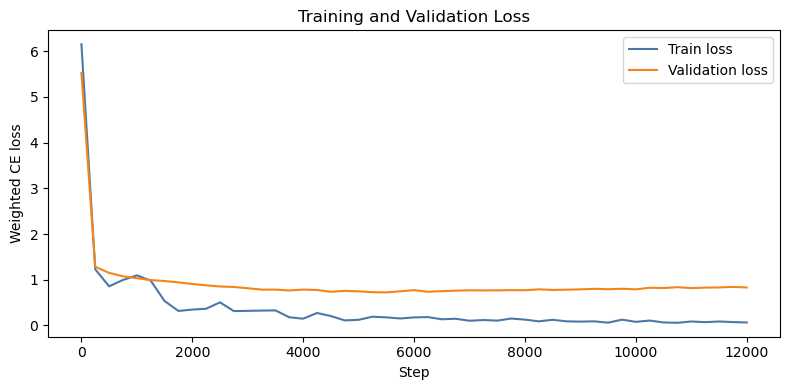

,scratch_initialized,pretrained_loaded,parameter_count,steps_completed,best_step,best_valid_loss,best_valid_perplexity,runtime_seconds
0,True,False,3422464,12000,5500,0.721808,2.058152,392.360344


In [10]:
history_path = METRICS_DIR / "training_history.csv"
if history_path.exists() and history_path.stat().st_size > 0:
    history_df = pd.read_csv(history_path)
    display(history_df.head())
    display(history_df.tail())
    if not history_df.empty:
        best_row = history_df.sort_values("valid_loss").head(1)
        display(best_row)
    fig, ax1 = plt.subplots(figsize=(8, 4))
    if "train_loss" in history_df:
        ax1.plot(history_df["step"], history_df["train_loss"], label="Train loss", color="#4C78A8")
    if "valid_loss" in history_df:
        ax1.plot(history_df["step"], history_df["valid_loss"], label="Validation loss", color="#F58518")
    ax1.set_title("Training and Validation Loss")
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Weighted CE loss")
    ax1.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "loss_curve.png", dpi=150)
    plt.show()
else:
    print("Training history not available yet. Run the training cell to populate this section.")

if (METRICS_DIR / "summary.json").exists():
    summary = json.loads((METRICS_DIR / "summary.json").read_text())
    display(pd.DataFrame([summary.get("transformer", {})]))


## 8. Candidate Generation


In [11]:
def strip_control_tokens(ids: list[int]) -> list[int]:
    return [int(i) for i in ids if int(i) < BASE_VOCAB_SIZE]

def sample_transformer(prefix: list[int], max_new_tokens: int, temperature: float, top_k: int) -> list[int]:
    blocked = torch.tensor(list(CONTROL_TOKEN_IDS.values()), dtype=torch.long, device=device)
    output = list(prefix)
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = output[-BLOCK_SIZE:]
            inputs = torch.tensor([context], dtype=torch.long, device=device)
            logits = model(input_ids=inputs).logits[0, -1, :] / max(temperature, 1e-6)
            logits[blocked] = -float("inf")
            values, indices = torch.topk(logits, k=min(top_k, BASE_VOCAB_SIZE))
            probs = torch.softmax(values, dim=-1)
            output.append(int(indices[torch.multinomial(probs, num_samples=1)].item()))
    return output

def write_note_events(path: Path, notes: list[dict[str, int]], ticks_per_beat: int) -> None:
    midi = mido.MidiFile(ticks_per_beat=ticks_per_beat)
    track = mido.MidiTrack()
    midi.tracks.append(track)
    track.append(mido.Message("program_change", program=0, time=0))
    events = []
    for note in notes:
        start = max(0, int(note["start"]))
        end = max(start + 1, int(note["end"]))
        pitch = max(0, min(127, int(note["pitch"])))
        velocity = max(1, min(127, int(note.get("velocity", 64))))
        channel = max(0, min(15, int(note.get("channel", 0))))
        events.append((start, 1, mido.Message("note_on", note=pitch, velocity=velocity, channel=channel, time=0)))
        events.append((end, 0, mido.Message("note_off", note=pitch, velocity=0, channel=channel, time=0)))
    events.sort(key=lambda x: (x[0], x[1]))
    previous = 0
    for absolute, _order, message in events:
        message.time = max(0, absolute - previous)
        track.append(message)
        previous = absolute
    path.parent.mkdir(parents=True, exist_ok=True)
    midi.save(path)

def crop_after(notes: list[dict[str, int]], split_tick: int) -> list[dict[str, int]]:
    cropped = []
    for note in notes:
        if note["end"] <= split_tick:
            continue
        shifted = dict(note)
        shifted["start"] = max(note["start"], split_tick) - split_tick
        shifted["end"] = note["end"] - split_tick
        if shifted["end"] > shifted["start"]:
            cropped.append(shifted)
    return cropped

def decode_candidate(ids: list[int], path: Path) -> bool:
    return decode_to_midi(strip_control_tokens(ids), path)

GENERATE_TOKENS = 768
TASK1_CANDIDATE_COUNT = 80
CONDITIONED_PREFIX_COUNT = 20
CONDITIONED_CANDIDATES_PER_PREFIX = 8
CONDITIONED_PREFIX_TOKENS = 128
TEMPERATURES = [0.7, 0.8, 0.9]
TOP_KS = [20, 50]

if RUN_GENERATION and (CHECKPOINT_DIR / "best_transformer.pt").exists():
    checkpoint = torch.load(CHECKPOINT_DIR / "best_transformer.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

generated_paths = []
settings = cycle(list(product(TEMPERATURES, TOP_KS)))

if RUN_GENERATION:
    for idx in range(TASK1_CANDIDATE_COUNT):
        temp, top_k = next(settings)
        ids = sample_transformer([CONTROL_TOKEN_IDS["high"], train_windows_raw[0][0]], GENERATE_TOKENS, temp, top_k)
        path = RAW_CANDIDATE_DIR / f"transformer_unconditioned_{idx:04d}_temp{temp}_topk{top_k}.mid"
        if decode_candidate(ids, path):
            generated_paths.append({"path": path, "task": "unconditioned", "model": "transformer", "temperature": temp, "top_k": top_k})

    prefix_records = []
    for prefix_id, sequence in enumerate(valid_sequences[:CONDITIONED_PREFIX_COUNT]):
        prefix_ids = sequence[:CONDITIONED_PREFIX_TOKENS]
        prefix_density = density_label(tokenizer, prefix_ids)
        control = "high" if prefix_density == "high" else "med"
        prefix_path = RAW_CANDIDATE_DIR / f"conditioned_prefix_{prefix_id:03d}.mid"
        decode_to_midi(prefix_ids, prefix_path)
        prefix_notes, prefix_tpb = read_note_events(prefix_path)
        split_tick = max((n["end"] for n in prefix_notes), default=0)
        prefix_records.append({"prefix_id": prefix_id, "prefix_path": prefix_path, "split_tick": split_tick, "control": control, "prefix_ids": prefix_ids})
        for local_idx in range(CONDITIONED_CANDIDATES_PER_PREFIX):
            temp, top_k = next(settings)
            ids = sample_transformer([CONTROL_TOKEN_IDS[control], *prefix_ids], GENERATE_TOKENS, temp, top_k)
            path = RAW_CANDIDATE_DIR / f"transformer_conditioned_prefix{prefix_id:03d}_{local_idx:03d}_temp{temp}_topk{top_k}.mid"
            if decode_candidate(ids, path):
                generated_paths.append({"path": path, "task": "conditioned", "model": "transformer", "temperature": temp, "top_k": top_k, "prefix_id": prefix_id, "prefix_path": prefix_path, "split_tick": split_tick})

print("Generated candidate count:", len(generated_paths))


Generated candidate count: 240


## 9. Candidate Evaluation and Ranking


Candidate ranking combines automatic validity checks with musical-density heuristics. The metrics include note count, total duration, first-note start, active duration, notes per second, active notes per second, maximum gap, pitch range, unique pitch count, maximum polyphony, and repetition. Hard rejects remove invalid, very sparse, overly dense, extremely long, very short, overly repetitive, or abnormal-polyphony candidates.

For conditioned generation, the ranking is based on the generated continuation only. This avoids selecting a candidate just because the real prefix sounds good in the full-with-prefix MIDI.


In [12]:
def max_polyphony(notes: list[dict[str, int]]) -> int:
    events = []
    for n in notes:
        events.append((n["start"], 1))
        events.append((n["end"], -1))
    events.sort(key=lambda x: (x[0], x[1]))
    active = 0
    peak = 0
    for _time, delta in events:
        active += delta
        peak = max(peak, active)
    return peak

def repetition_rate(notes: list[dict[str, int]]) -> float:
    pitches = [n["pitch"] for n in sorted(notes, key=lambda n: (n["start"], n["pitch"]))]
    if len(pitches) < 2:
        return 0.0
    bigrams = list(zip(pitches, pitches[1:]))
    counts = Counter(bigrams)
    return sum(v - 1 for v in counts.values() if v > 1) / max(len(bigrams), 1)

def metric_from_notes(path: Path, notes: list[dict[str, int]], ticks_per_beat: int) -> dict[str, object]:
    if not notes:
        return {"path": str(path), "valid": False, "note_count": 0, "duration_seconds": 0.0, "notes_per_second": 0.0}
    starts = [n["start"] for n in notes]
    ends = [n["end"] for n in notes]
    pitches = [n["pitch"] for n in notes]
    start_seconds = sorted(s / ticks_per_beat * 0.5 for s in starts)
    gaps = [b - a for a, b in zip(start_seconds, start_seconds[1:])]
    duration = max(ends) / ticks_per_beat * 0.5
    first = min(starts) / ticks_per_beat * 0.5
    active_duration = (max(ends) - min(starts)) / ticks_per_beat * 0.5
    return {
        "path": relpath(path),
        "valid": True,
        "note_count": len(notes),
        "duration_seconds": duration,
        "first_note_start": first,
        "active_duration": active_duration,
        "notes_per_second": len(notes) / max(duration, 1e-9),
        "notes_per_second_active": len(notes) / max(active_duration, 1e-9),
        "max_gap": max(gaps) if gaps else 0.0,
        "pitch_range": max(pitches) - min(pitches),
        "unique_pitch_count": len(set(pitches)),
        "max_polyphony": max_polyphony(notes),
        "repetition": repetition_rate(notes),
    }

def analyze_midi(path: Path) -> dict[str, object]:
    try:
        notes, ticks_per_beat = read_note_events(path)
        return metric_from_notes(path, notes, ticks_per_beat)
    except Exception as exc:
        return {"path": str(path), "valid": False, "note_count": 0, "reject_reason": repr(exc)}

def reject_reason(row: dict[str, object], min_notes: int = 100) -> str:
    reasons = []
    if not row.get("valid", False):
        reasons.append("invalid")
    if float(row.get("note_count", 0) or 0) < min_notes:
        reasons.append(f"note_count_lt_{min_notes}")
    if float(row.get("duration_seconds", 0) or 0) < 25:
        reasons.append("duration_lt_25")
    if float(row.get("duration_seconds", 0) or 0) > 90:
        reasons.append("duration_gt_90")
    if float(row.get("notes_per_second", 0) or 0) < 1.5:
        reasons.append("notes_per_second_lt_1p5")
    if float(row.get("notes_per_second", 0) or 0) > 8:
        reasons.append("notes_per_second_gt_8")
    if float(row.get("max_gap", 0) or 0) > 4:
        reasons.append("max_gap_gt_4")
    if float(row.get("max_polyphony", 0) or 0) > 32:
        reasons.append("polyphony_gt_32")
    if float(row.get("pitch_range", 0) or 0) < 8:
        reasons.append("pitch_range_lt_8")
    if float(row.get("repetition", 0) or 0) > 0.9:
        reasons.append("repetition_gt_0p9")
    return ";".join(reasons)

def blank_reason(value) -> bool:
    return pd.isna(value) or str(value).strip() == "" or str(value).strip().lower() == "nan"

def normalized_reason(value) -> str:
    return "" if blank_reason(value) else str(value).strip()

def score_candidate(row: dict[str, object]) -> float:
    if not blank_reason(row.get("reject_reason", "")):
        return -1_000_000_000.0
    duration = float(row.get("duration_seconds", 0) or 0)
    nps = float(row.get("notes_per_second", 0) or 0)
    gap = float(row.get("max_gap", 0) or 0)
    notes = float(row.get("note_count", 0) or 0)
    return 2.0 - abs(duration - 50) / 50 - abs(nps - 3.0) / 3.0 - max(0, gap - 2) * 0.25 + min(notes, 250) / 250

candidate_rows = []
if RUN_EVALUATION:
    for record in generated_paths:
        row = analyze_midi(record["path"])
        row.update(record)
        if record["task"] == "conditioned":
            notes, ticks_per_beat = read_note_events(record["path"])
            continuation_notes = crop_after(notes, int(record["split_tick"]))
            cont = metric_from_notes(record["path"], continuation_notes, ticks_per_beat)
            cont["reject_reason"] = normalized_reason(reject_reason(cont, min_notes=100))
            cont["usable"] = blank_reason(cont["reject_reason"])
            cont["score"] = score_candidate(cont)
            for key, value in cont.items():
                row[f"continuation_{key}"] = value
            row["rank_score"] = cont["score"]
            row["rank_reject_reason"] = normalized_reason(cont["reject_reason"])
        else:
            row["reject_reason"] = normalized_reason(reject_reason(row, min_notes=100))
            row["usable"] = blank_reason(row["reject_reason"])
            row["score"] = score_candidate(row)
            row["rank_score"] = row["score"]
            row["rank_reject_reason"] = normalized_reason(row["reject_reason"])
        candidate_rows.append(row)

    # Baseline metrics.
    for path, task in [(CANDIDATE_DIR / "markov_unconditioned.mid", "unconditioned"), (CANDIDATE_DIR / "markov_conditioned.mid", "conditioned")]:
        if path.exists():
            row = analyze_midi(path)
            reason = normalized_reason(reject_reason(row))
            row.update({"task": task, "model": "markov", "rank_score": score_candidate({**row, "reject_reason": reason}), "rank_reject_reason": reason})
            row["usable"] = blank_reason(row["rank_reject_reason"])
            candidate_rows.append(row)

ranking_df = pd.DataFrame(candidate_rows)
if not ranking_df.empty:
    ranking_df["rank_reject_reason"] = ranking_df["rank_reject_reason"].apply(normalized_reason)
    ranking_df.to_csv(EVALUATION_DIR / "candidate_ranking.csv", index=False)
    diagnostics = ranking_df.copy()
    diagnostics.to_csv(EVALUATION_DIR / "candidate_diagnostics.csv", index=False)
    display(ranking_df.sort_values("rank_score", ascending=False).head(12))

    usable_mask = ranking_df["rank_reject_reason"].apply(blank_reason)
    transformer_uncond = ranking_df[(ranking_df["model"] == "transformer") & (ranking_df["task"] == "unconditioned") & usable_mask]
    transformer_cond = ranking_df[(ranking_df["model"] == "transformer") & (ranking_df["task"] == "conditioned") & usable_mask]
    selected = []
    if not transformer_uncond.empty:
        best = transformer_uncond.sort_values("rank_score", ascending=False).iloc[0]
        shutil.copy2(PROJECT_ROOT / best["path"], CANDIDATE_DIR / "symbolic_unconditioned.mid")
        selected.append({**best.to_dict(), "selected_path": relpath(CANDIDATE_DIR / "symbolic_unconditioned.mid")})
    if not transformer_cond.empty:
        best = transformer_cond.sort_values("rank_score", ascending=False).iloc[0]
        source = PROJECT_ROOT / best["path"]
        shutil.copy2(source, CANDIDATE_DIR / "symbolic_conditioned.mid")
        shutil.copy2(source, CANDIDATE_DIR / "conditioned_full_with_prefix.mid")
        prefix_path = Path(best["prefix_path"])
        if not prefix_path.is_absolute():
            prefix_path = PROJECT_ROOT / prefix_path
        shutil.copy2(prefix_path, CANDIDATE_DIR / "conditioned_prefix_only.mid")
        notes, ticks_per_beat = read_note_events(source)
        continuation_notes = crop_after(notes, int(best["split_tick"]))
        write_note_events(CANDIDATE_DIR / "conditioned_continuation_only.mid", continuation_notes, ticks_per_beat)
        selected.append({**best.to_dict(), "selected_path": relpath(CANDIDATE_DIR / "symbolic_conditioned.mid"), "continuation_only_path": relpath(CANDIDATE_DIR / "conditioned_continuation_only.mid")})

    selected_df = pd.DataFrame(selected)
    selected_df.to_csv(EVALUATION_DIR / "selected_candidates.csv", index=False)
    display(selected_df)

    model_metrics = pd.DataFrame([{
        "model": "density_conditioned_transformer",
        "best_checkpoint": relpath(CHECKPOINT_DIR / "best_transformer.pt"),
        "best_step": summary.get("transformer", {}).get("best_step"),
        "best_valid_loss": summary.get("transformer", {}).get("best_valid_loss"),
        "best_valid_perplexity": summary.get("transformer", {}).get("best_valid_perplexity"),
    }])
    model_metrics.to_csv(EVALUATION_DIR / "model_metrics.csv", index=False)


,path,valid,note_count,duration_seconds,first_note_start,active_duration,notes_per_second,notes_per_second_active,max_gap,pitch_range,...,continuation_notes_per_second,continuation_notes_per_second_active,continuation_max_gap,continuation_pitch_range,continuation_unique_pitch_count,continuation_max_polyphony,continuation_repetition,continuation_reject_reason,continuation_usable,continuation_score
23,outputs\final\candidates\raw\transformer_uncon...,True,159,51.50,1.0,50.50,3.087379,3.148515,1.25,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,outputs\final\candidates\raw\transformer_uncon...,True,179,52.50,1.0,51.50,3.409524,3.475728,2.00,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,outputs\final\candidates\raw\transformer_uncon...,True,188,57.50,1.0,56.50,3.269565,3.327434,1.50,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,outputs\final\candidates\raw\transformer_uncon...,True,148,47.50,1.0,46.50,3.115789,3.182796,1.25,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,outputs\final\candidates\raw\transformer_uncon...,True,193,59.25,1.0,58.25,3.257384,3.313305,1.25,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,outputs\final\candidates\raw\transformer_uncon...,True,167,57.50,1.0,56.50,2.904348,2.955752,1.50,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,outputs\final\candidates\raw\transformer_uncon...,True,228,59.25,1.0,58.25,3.848101,3.914163,1.00,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,outputs\final\candidates\raw\transformer_uncon...,True,149,46.00,1.0,45.00,3.239130,3.311111,1.00,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,outputs\final\candidates\raw\transformer_uncon...,True,235,70.25,1.0,69.25,3.345196,3.393502,1.75,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,outputs\final\candidates\raw\transformer_uncon...,True,132,44.75,1.0,43.75,2.949721,3.017143,1.00,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,path,valid,note_count,duration_seconds,first_note_start,active_duration,notes_per_second,notes_per_second_active,max_gap,pitch_range,...,continuation_max_gap,continuation_pitch_range,continuation_unique_pitch_count,continuation_max_polyphony,continuation_repetition,continuation_reject_reason,continuation_usable,continuation_score,selected_path,continuation_only_path
0,outputs\final\candidates\raw\transformer_uncon...,True,159,51.5,1.0,50.5,3.087379,3.148515,1.25,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,outputs\final\candidates\symbolic_unconditione...,NaN
1,outputs\final\candidates\raw\transformer_condi...,True,381,111.5,1.5,110.0,3.417040,3.463636,1.50,42,...,1.5,42.0,15.0,4.0,0.818182,,True,2.279726,outputs\final\candidates\symbolic_conditioned.mid,outputs\final\candidates\conditioned_continuat...


C:\Users\GD\AppData\Local\Temp\ipykernel_29920\2056053568.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


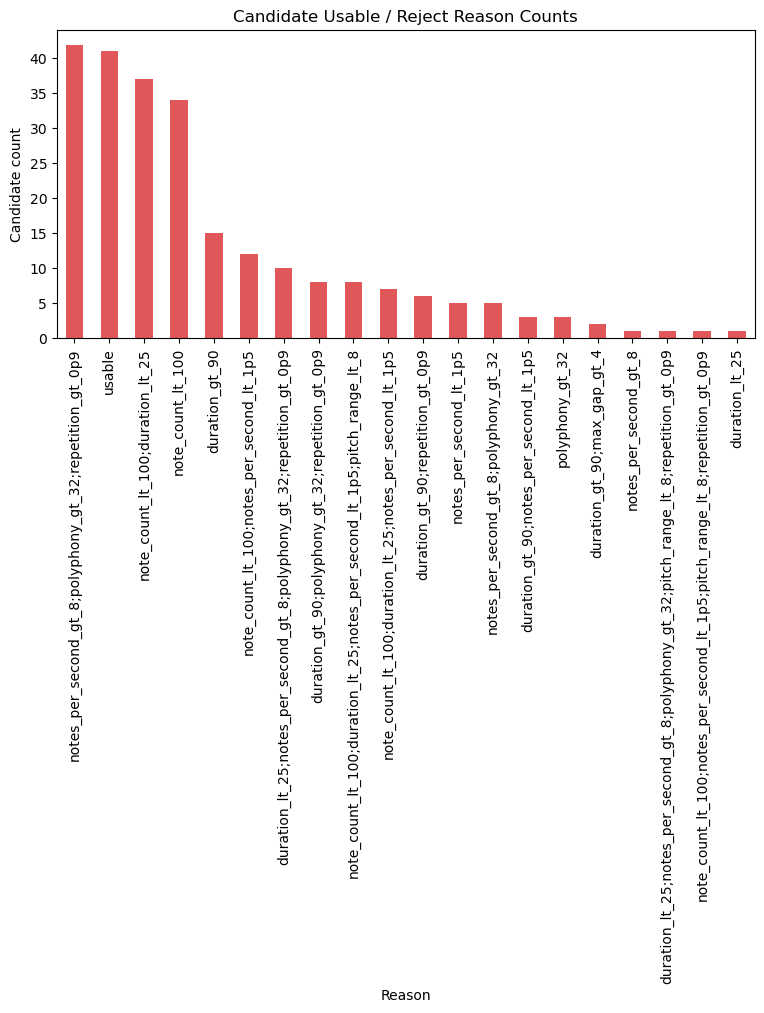

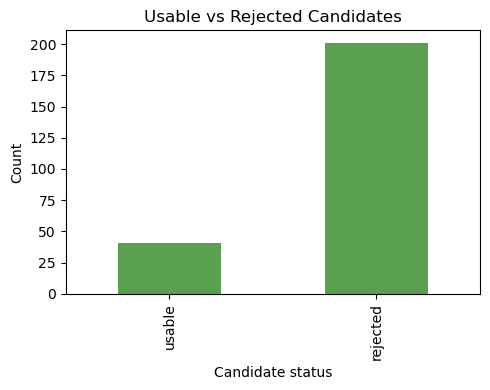

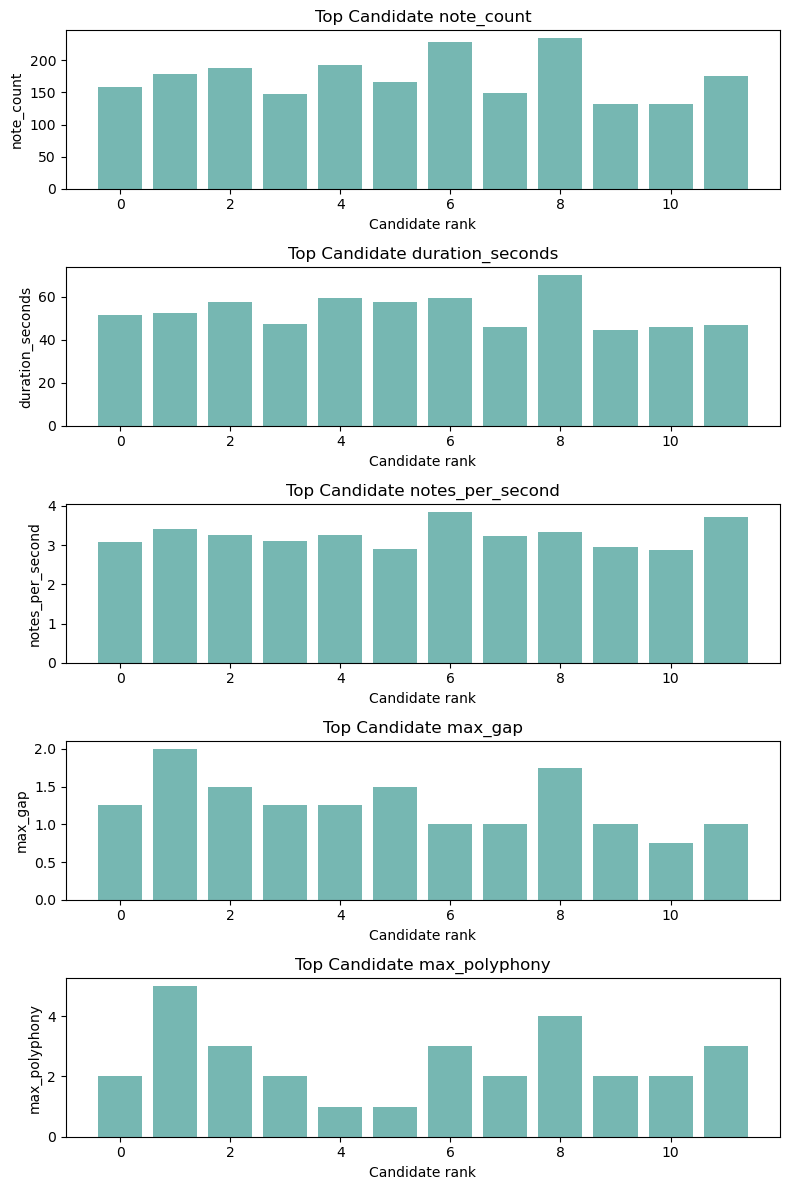

In [13]:
if not ranking_df.empty:
    reason_series = ranking_df["rank_reject_reason"].apply(normalized_reason)
    reject_counts = reason_series.replace("", "usable").value_counts()
    fig, ax = plt.subplots(figsize=(9, 4))
    reject_counts.plot(kind="bar", ax=ax, color="#E15759")
    ax.set_title("Candidate Usable / Reject Reason Counts")
    ax.set_xlabel("Reason")
    ax.set_ylabel("Candidate count")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "candidate_reject_reason_bar.png", dpi=150)
    plt.show()

    usable_counts = pd.Series({
        "usable": int(reason_series.apply(blank_reason).sum()),
        "rejected": int((~reason_series.apply(blank_reason)).sum()),
    })
    fig, ax = plt.subplots(figsize=(5, 4))
    usable_counts.plot(kind="bar", ax=ax, color="#59A14F")
    ax.set_title("Usable vs Rejected Candidates")
    ax.set_xlabel("Candidate status")
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "candidate_usable_vs_rejected.png", dpi=150)
    plt.show()

    metrics = ["note_count", "duration_seconds", "notes_per_second", "max_gap", "max_polyphony"]
    comparison = ranking_df.sort_values("rank_score", ascending=False).head(12)
    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 12))
    for ax, metric in zip(axes, metrics):
        ax.bar(range(len(comparison)), comparison[metric].fillna(0), color="#76B7B2")
        ax.set_title(f"Top Candidate {metric}")
        ax.set_xlabel("Candidate rank")
        ax.set_ylabel(metric)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "candidate_metric_comparison.png", dpi=150)
    plt.show()


## 10. Results Section Placeholder

After running the notebook, the final selected candidates and metrics are shown below.

In [14]:
selected_path = EVALUATION_DIR / "selected_candidates.csv"
model_metrics_path = EVALUATION_DIR / "model_metrics.csv"
diagnostics_path = EVALUATION_DIR / "candidate_diagnostics.csv"

if selected_path.exists():
    selected_display = pd.read_csv(selected_path)
    display(selected_display)
else:
    print("No selected candidates yet.")

if model_metrics_path.exists():
    display(pd.read_csv(model_metrics_path))

if diagnostics_path.exists():
    diag = pd.read_csv(diagnostics_path)
    display(diag.groupby(["model", "task"], dropna=False).size().reset_index(name="candidate_count"))


,path,valid,note_count,duration_seconds,first_note_start,active_duration,notes_per_second,notes_per_second_active,max_gap,pitch_range,...,continuation_max_gap,continuation_pitch_range,continuation_unique_pitch_count,continuation_max_polyphony,continuation_repetition,continuation_reject_reason,continuation_usable,continuation_score,selected_path,continuation_only_path
0,outputs\final\candidates\raw\transformer_uncon...,True,159,51.5,1.0,50.5,3.087379,3.148515,1.25,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,outputs\final\candidates\symbolic_unconditione...,NaN
1,outputs\final\candidates\raw\transformer_condi...,True,381,111.5,1.5,110.0,3.417040,3.463636,1.50,42,...,1.5,42.0,15.0,4.0,0.818182,NaN,True,2.279726,outputs\final\candidates\symbolic_conditioned.mid,outputs\final\candidates\conditioned_continuat...


,model,best_checkpoint,best_step,best_valid_loss,best_valid_perplexity
0,density_conditioned_transformer,outputs\final\checkpoints\best_transformer.pt,5500,0.721808,2.058152


,model,task,candidate_count
0,markov,conditioned,1
1,markov,unconditioned,1
2,transformer,conditioned,160
3,transformer,unconditioned,80


## 11. Baseline Comparison


The comparison table reads the current evaluation CSVs and compares the best Markov and Transformer candidates for both tasks. For the Transformer conditioned row, the displayed metrics come from the continuation-only segment so that the table reflects generated music rather than the real input prefix.


In [15]:
def metric_value(row, preferred: str, fallback: str):
    value = row.get(preferred)
    if pd.isna(value):
        return row.get(fallback)
    return value

comparison_rows = []
if EVALUATION_DIR.joinpath("candidate_ranking.csv").exists():
    df = pd.read_csv(EVALUATION_DIR / "candidate_ranking.csv")
    if "rank_reject_reason" in df:
        df["rank_reject_reason"] = df["rank_reject_reason"].apply(normalized_reason)
    for model_name, task in [("markov", "unconditioned"), ("markov", "conditioned"), ("transformer", "unconditioned"), ("transformer", "conditioned")]:
        subset = df[(df["model"] == model_name) & (df["task"] == task)].copy()
        if subset.empty:
            continue
        subset = subset.sort_values("rank_score", ascending=False)
        row = subset.iloc[0]
        use_continuation = task == "conditioned" and model_name == "transformer"
        reason = metric_value(row, "continuation_reject_reason", "rank_reject_reason") if use_continuation else row.get("rank_reject_reason", "")
        comparison_rows.append({
            "model": model_name,
            "task": task,
            "note_count": metric_value(row, "continuation_note_count", "note_count") if use_continuation else row.get("note_count"),
            "duration_seconds": metric_value(row, "continuation_duration_seconds", "duration_seconds") if use_continuation else row.get("duration_seconds"),
            "notes_per_second": metric_value(row, "continuation_notes_per_second", "notes_per_second") if use_continuation else row.get("notes_per_second"),
            "max_gap": metric_value(row, "continuation_max_gap", "max_gap") if use_continuation else row.get("max_gap"),
            "max_polyphony": metric_value(row, "continuation_max_polyphony", "max_polyphony") if use_continuation else row.get("max_polyphony"),
            "usable": blank_reason(reason),
            "comment": "baseline" if model_name == "markov" else "main model",
        })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,model,task,note_count,duration_seconds,notes_per_second,max_gap,max_polyphony,usable,comment
0,markov,unconditioned,375.0,216.25,1.734104,6.50,14.0,False,baseline
1,markov,conditioned,504.0,212.25,2.374558,6.00,18.0,False,baseline
2,transformer,unconditioned,159.0,51.50,3.087379,1.25,2.0,True,main model
3,transformer,conditioned,276.0,73.00,3.780822,1.50,4.0,True,main model


## 12. Failure Analysis

MAESTRO was tried as a harder expressive piano dataset. It exposed an important failure mode: full prefix-conditioned MIDI can sound better than the generated continuation because the real prefix contributes musical structure. Continuation-only diagnostics also showed sparse generated outputs with long durations and too few effective notes.

The final route therefore uses Nottingham and adds density-conditioned training. The density token and balanced window sampling are meant to reduce long-duration / low-note-density failures without relying on post-processing to hide sparse generation.


## 13. Final Selected Outputs


The two final files map directly to the assignment tasks. `symbolic_unconditioned.mid` is the Task 1 fully generated Transformer output with no real primer. `symbolic_conditioned.mid` is the Task 2 conditioned Transformer output, and its selection is based on continuation-only metrics to avoid prefix leakage. Markov files remain baseline comparison artifacts, and conditioned split files are diagnostic aids.


In [16]:
final_mapping = pd.DataFrame([
    {
        "task": "Task 1 symbolic unconditioned generation",
        "final submission filename": "symbolic_unconditioned.mid",
        "source path in outputs/final/candidates/": relpath(CANDIDATE_DIR / "symbolic_unconditioned.mid"),
        "model": "density-conditioned Transformer",
        "generation mode": "BOS / fully generated",
        "notes": "no real primer used",
    },
    {
        "task": "Task 2 symbolic conditioned continuation",
        "final submission filename": "symbolic_conditioned.mid",
        "source path in outputs/final/candidates/": relpath(CANDIDATE_DIR / "symbolic_conditioned.mid"),
        "model": "density-conditioned Transformer",
        "generation mode": "conditioned continuation",
        "notes": "evaluated using continuation-only to avoid prefix leakage",
    },
])
display(final_mapping)

expected_outputs = [
    CANDIDATE_DIR / "symbolic_unconditioned.mid",
    CANDIDATE_DIR / "symbolic_conditioned.mid",
    CANDIDATE_DIR / "markov_unconditioned.mid",
    CANDIDATE_DIR / "markov_conditioned.mid",
    CANDIDATE_DIR / "conditioned_prefix_only.mid",
    CANDIDATE_DIR / "conditioned_full_with_prefix.mid",
    CANDIDATE_DIR / "conditioned_continuation_only.mid",
]
for path in expected_outputs:
    print(path, "exists=", path.exists())

print("\nAfter final review, the two selected Transformer files can be copied to:")
print("submission/symbolic_unconditioned.mid")
print("submission/symbolic_conditioned.mid")


,task,final submission filename,source path in outputs/final/candidates/,model,generation mode,notes
0,Task 1 symbolic unconditioned generation,symbolic_unconditioned.mid,outputs\final\candidates\symbolic_unconditione...,density-conditioned Transformer,BOS / fully generated,no real primer used
1,Task 2 symbolic conditioned continuation,symbolic_conditioned.mid,outputs\final\candidates\symbolic_conditioned.mid,density-conditioned Transformer,conditioned continuation,evaluated using continuation-only to avoid pre...


outputs\final\candidates\symbolic_unconditioned.mid exists= True
outputs\final\candidates\symbolic_conditioned.mid exists= True
outputs\final\candidates\markov_unconditioned.mid exists= True
outputs\final\candidates\markov_conditioned.mid exists= True
outputs\final\candidates\conditioned_prefix_only.mid exists= True
outputs\final\candidates\conditioned_full_with_prefix.mid exists= True
outputs\final\candidates\conditioned_continuation_only.mid exists= True

After final review, the two selected Transformer files can be copied to:
submission/symbolic_unconditioned.mid
submission/symbolic_conditioned.mid


### Files to Listen To


In [17]:
listen_paths = pd.DataFrame([
    {"role": "final selected Task 1", "path": relpath(CANDIDATE_DIR / "symbolic_unconditioned.mid"), "note": "Transformer unconditioned"},
    {"role": "final selected Task 2", "path": relpath(CANDIDATE_DIR / "symbolic_conditioned.mid"), "note": "Transformer conditioned full output"},
    {"role": "baseline Task 1", "path": relpath(CANDIDATE_DIR / "markov_unconditioned.mid"), "note": "Markov baseline"},
    {"role": "baseline Task 2", "path": relpath(CANDIDATE_DIR / "markov_conditioned.mid"), "note": "Markov baseline"},
    {"role": "conditioned diagnostic", "path": relpath(CANDIDATE_DIR / "conditioned_prefix_only.mid"), "note": "real prefix only"},
    {"role": "conditioned diagnostic", "path": relpath(CANDIDATE_DIR / "conditioned_full_with_prefix.mid"), "note": "prefix plus generated continuation"},
    {"role": "conditioned diagnostic", "path": relpath(CANDIDATE_DIR / "conditioned_continuation_only.mid"), "note": "generated continuation only"},
])
display(listen_paths)


,role,path,note
0,final selected Task 1,outputs\final\candidates\symbolic_unconditione...,Transformer unconditioned
1,final selected Task 2,outputs\final\candidates\symbolic_conditioned.mid,Transformer conditioned full output
2,baseline Task 1,outputs\final\candidates\markov_unconditioned.mid,Markov baseline
3,baseline Task 2,outputs\final\candidates\markov_conditioned.mid,Markov baseline
4,conditioned diagnostic,outputs\final\candidates\conditioned_prefix_on...,real prefix only
5,conditioned diagnostic,outputs\final\candidates\conditioned_full_with...,prefix plus generated continuation
6,conditioned diagnostic,outputs\final\candidates\conditioned_continuat...,generated continuation only


## 14. Submission Checklist

Submission creation is intentionally disabled in this notebook revision. After review, the final submission should include:

- `workbook.html`
- `video_url.txt`
- `symbolic_unconditioned.mid`
- `symbolic_conditioned.mid`

Future manual steps, not executed here:

1. Export this notebook to HTML.
2. Create `submission/`.
3. Copy `outputs/final/candidates/symbolic_unconditioned.mid`.
4. Copy `outputs/final/candidates/symbolic_conditioned.mid`.
5. Create `video_url.txt`.


In [18]:
assert CREATE_SUBMISSION_FILES is False
assert EXPORT_HTML is False
print("Submission creation disabled:", not CREATE_SUBMISSION_FILES)
print("HTML export disabled:", not EXPORT_HTML)


Submission creation disabled: True
HTML export disabled: True
